# Análisis Exploratorio de Datos — Alojamientos Turísticos
**Equip 26 | Analista: Patricia Proniewska | 21 Abril 2026**

---

## Índice
1. Configuración y conexión a la base de datos
2. Exploración inicial (EDA)
   - 2.1 Dimensiones y tipos de datos
   - 2.2 Valores nulos
   - 2.3 Resúmenes estadísticos
   - 2.4 Visualizaciones iniciales
   - 2.5 Correlaciones entre variables
   - 2.6 Análisis — Marketing y Estrategia Comercial
   - 2.7 Análisis — Experiencia del Cliente
3. Conclusiones

## 1. Configuración y conexión a la base de datos

Conexión a la base de datos remota del equipo. 
Credenciales gestionadas de forma segura mediante `getpass`.

In [7]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass

# Conexión a la base de datos
password = getpass.getpass("Introduce la contraseña MySQL: ")

conn = mysql.connector.connect(
    host="212.227.90.6",
    user="Equipo26",
    password=password,
    database="Equip_26"
)

df_alojamientos = pd.read_sql("SELECT * FROM Tourist_Accommodation", conn)
conn.close()

print("Conexión exitosa ✅")
print(f"Datos cargados: {df_alojamientos.shape[0]} filas, {df_alojamientos.shape[1]} columnas")


/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_56686/1995059207.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_alojamientos = pd.read_sql("SELECT * FROM Tourist_Accommodation", conn)


Conexión exitosa ✅
Datos cargados: 7001 filas, 35 columnas


## 2. Exploración inicial (EDA)

### 2.1 Resúmenes estadísticos

In [8]:
# Dimensiones del dataset
print(f"Filas: {df_alojamientos.shape[0]} | Columnas: {df_alojamientos.shape[1]}")

# Tipos de datos
df_alojamientos.info()

Filas: 7001 | Columnas: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7001 entries, 0 to 7000
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 7001 non-null   int64  
 1   name                         6998 non-null   object 
 2   description                  6972 non-null   object 
 3   host_id                      7001 non-null   int64  
 4   neighbourhood_name           7001 non-null   object 
 5   neighbourhood_district       4241 non-null   object 
 6   room_type                    7001 non-null   object 
 7   accommodates                 7001 non-null   int64  
 8   bathrooms                    6969 non-null   object 
 9   bedrooms                     6972 non-null   object 
 10  beds                         6998 non-null   float64
 11  amenities_list               6984 non-null   object 
 12  price                        6870 non-null   floa

### 2.2 Valores nulos

In [9]:
# Valores nulos por columna
nulos = df_alojamientos.isnull().sum()
nulos[nulos > 0].sort_values(ascending=False)

neighbourhood_district         2760
review_scores_value            1342
review_scores_location         1342
review_scores_checkin          1341
review_scores_accuracy         1336
review_scores_communication    1332
review_scores_cleanliness      1330
review_scores_rating           1327
last_review_date               1255
first_review_date              1254
reviews_per_month              1254
has_availability                550
price                           131
bathrooms                        32
description                      29
bedrooms                         29
amenities_list                   17
name                              3
beds                              3
dtype: int64

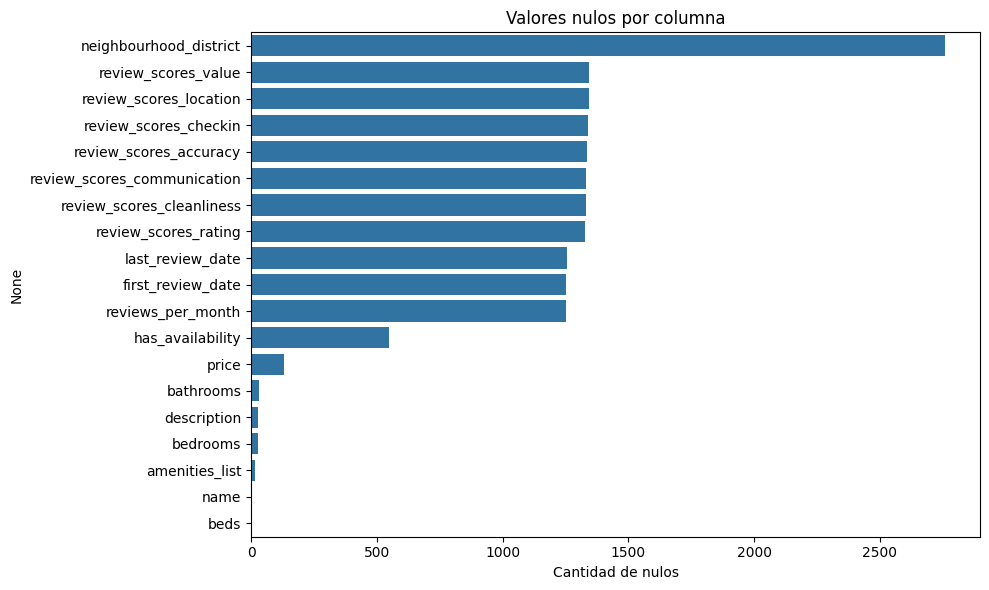

In [10]:
# Visualización de valores nulos
nulos = df_alojamientos.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=nulos.values, y=nulos.index)
plt.title("Valores nulos por columna")
plt.xlabel("Cantidad de nulos")
plt.tight_layout()
plt.show()

In [11]:
# Nulos en variables relevantes para esta semana
columnas_relevantes = ['review_scores_rating', 'price', 'room_type', 'city']
nulos_relevantes = df_alojamientos[columnas_relevantes].isnull().sum()
print(nulos_relevantes)

review_scores_rating    1327
price                    131
room_type                  0
city                       0
dtype: int64


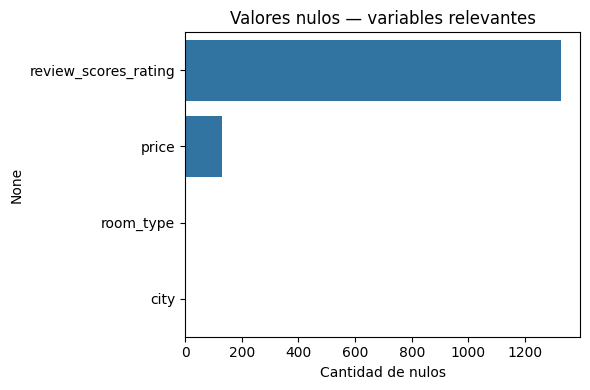

In [12]:
plt.figure(figsize=(6, 4))
sns.barplot(x=nulos_relevantes.values, y=nulos_relevantes.index)
plt.title("Valores nulos — variables relevantes")
plt.xlabel("Cantidad de nulos")
plt.tight_layout()
plt.show()

### Observaciones — Valores nulos (variables relevantes)

- **`city`** y **`room_type`**: sin nulos ✅ — listas para el análisis.
- **`price`**: 131 nulos (1.8%) — impacto bajo para el análisis de Marketing.
- **`review_scores_rating`**: 1.327 nulos (19%) — impacto significativo para el análisis 
de Experiencia del Cliente.

> ⚠️ Se recomienda al equipo de limpieza tratar `review_scores_rating` 
antes del análisis final.

### 2.3 Resúmenes estadísticos

In [16]:
# Estadísticas descriptivas de variables relevantes
df_alojamientos[['review_scores_rating', 'price', 'room_type']].describe().round(2)


,review_scores_rating,price
count,5674.00,6870.00
mean,920.23,1011.10
std,85.35,845.98
min,200.00,60.00
25%,890.00,450.00
50%,940.00,750.00
75%,980.00,1230.00
max,1000.00,6071.00


### Observaciones — Resúmenes estadísticos

- `review_scores_rating`**: media de 920/1000. Valoraciones generalmente altas. 
Valor mínimo de 200 sugiere posibles outliers a revisar.
- `price`**: alta dispersión (std: 845). Rango entre 60 y 6.071. 
La mediana (750) es más representativa que la media (1.011) debido a valores extremos.

### 2.4 Visualizaciones iniciales

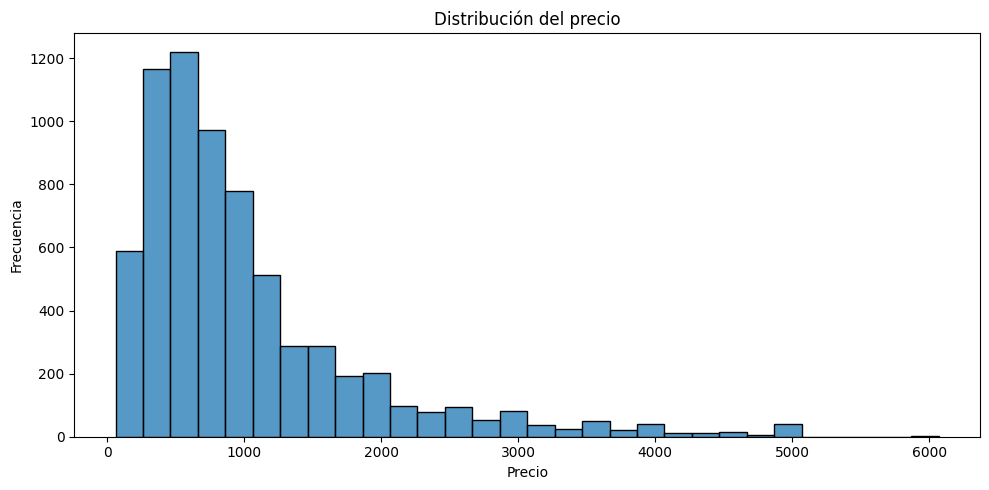

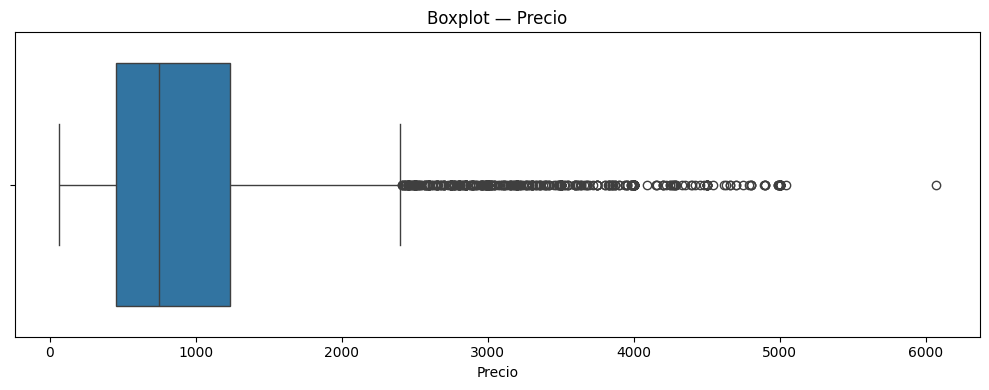

In [18]:
# Distribución del precio
plt.figure(figsize=(10, 5))
sns.histplot(df_alojamientos['price'].dropna(), bins=30)
plt.title("Distribución del precio")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Boxplot precio
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_alojamientos['price'].dropna())
plt.title("Boxplot — Precio")
plt.xlabel("Precio")
plt.tight_layout()
plt.show()

### Observaciones — Precio

- La mayoría de alojamientos tienen precios asequibles, aunque existe 
un segmento reducido de alojamientos de lujo con precios muy superiores.
- La mayoría de alojamientos tienen precios entre 200 y 1.000.
- Se detectan outliers significativos por encima de 2.500.
- Se recomienda al equipo de limpieza revisar los valores extremos 
antes del análisis de precio medio.

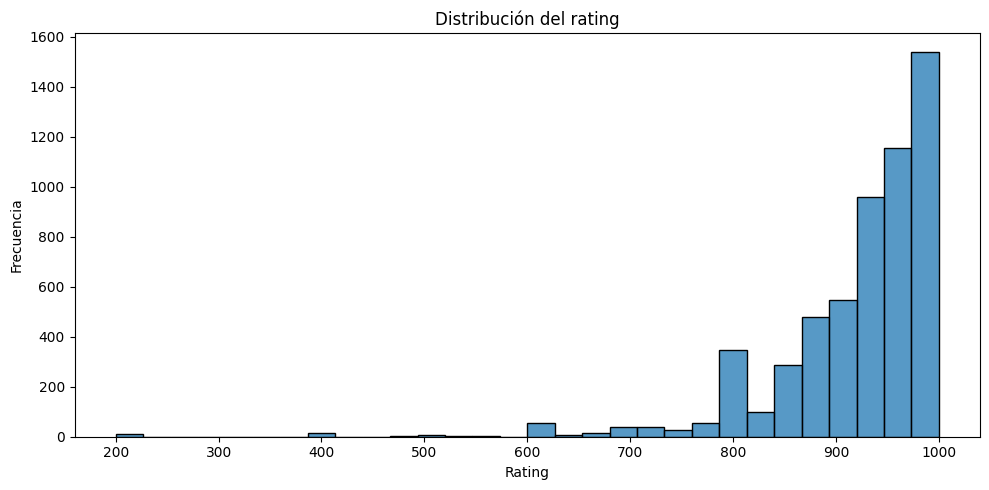

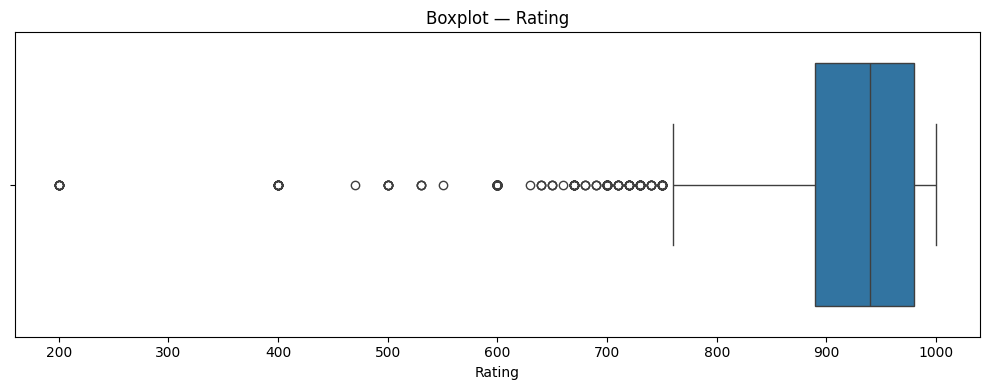

In [19]:
# Distribución del rating
plt.figure(figsize=(10, 5))
sns.histplot(df_alojamientos['review_scores_rating'].dropna(), bins=30)
plt.title("Distribución del rating")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Boxplot rating
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_alojamientos['review_scores_rating'].dropna())
plt.title("Boxplot — Rating")
plt.xlabel("Rating")
plt.tight_layout()
plt.show()

### Observaciones — Rating

- La gran mayoría de alojamientos tienen valoraciones entre 800 y 1.000, 
lo que indica una oferta turística de alta calidad general.
- Se detectan outliers a la baja — alojamientos con ratings muy bajos (200-600) 
que representan valoraciones reales de clientes insatisfechos.

### 2.5 Correlaciones entre variables relevantes


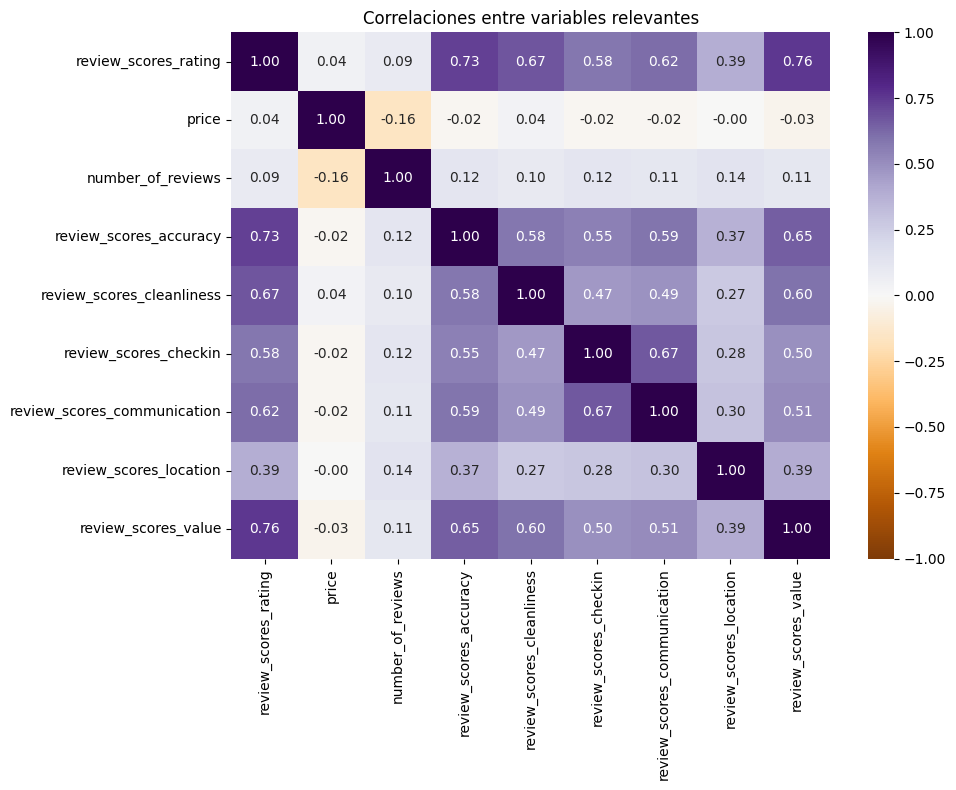

In [22]:
# Correlaciones entre variables relevantes
columnas_corr = [
    'review_scores_rating', 'price', 'number_of_reviews',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_alojamientos[columnas_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='PuOr',
    vmin=-1,
    vmax=1
)
plt.title("Correlaciones entre variables relevantes")
plt.tight_layout()
plt.show()

### Observaciones — Correlaciones

- La valoración general (`review_scores_rating`) correlaciona fuertemente con 
`review_scores_value` (0.76) y `review_scores_accuracy` (0.73).
- El precio tiene correlación casi nula con el rating (0.04) — 
un alojamiento caro no garantiza mejor valoración.
- La limpieza y la precisión del anuncio son los factores 
más determinantes en la satisfacción del cliente.

 ### 2.6 Análisis — Marketing y Estrategia Comercial

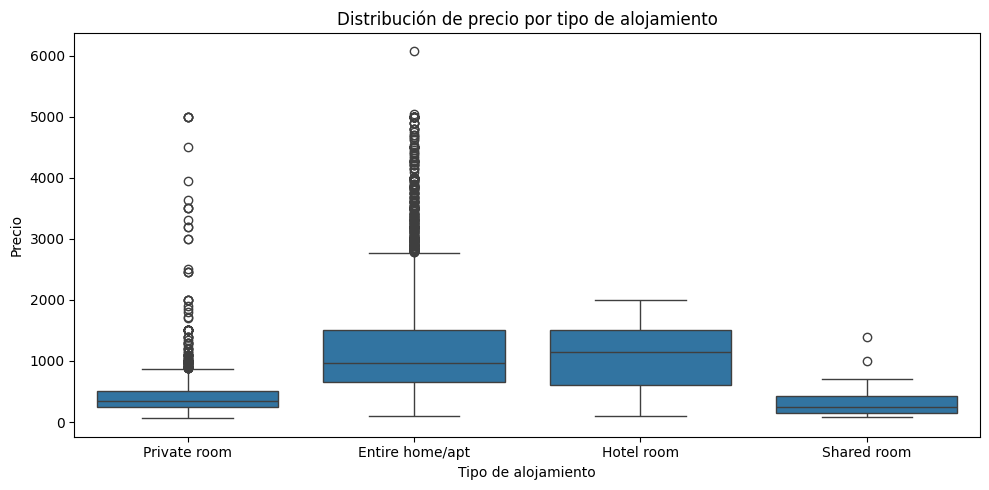

In [23]:
# Distribución de precio por tipo de alojamiento
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_alojamientos, x='room_type', y='price')
plt.title("Distribución de precio por tipo de alojamiento")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Precio")
plt.tight_layout()
plt.show()

### Observaciones — Precio por tipo de alojamiento

- Los alojamientos completos (Entire home/apt) y habitaciones de hotel 
son los más caros, con mayor dispersión de precios.
- Las habitaciones privadas y compartidas tienen precios significativamente 
más bajos y consistentes.
- Se detectan outliers en Entire home/apt — alojamientos de lujo 
con precios superiores a 4.000.

In [24]:
# Precio mediano por tipo de alojamiento y ciudad
precio_medio = df_alojamientos.groupby(['city', 'room_type'])['price'].median().round(2).reset_index()
precio_medio.columns = ['Ciudad', 'Tipo de alojamiento', 'Precio mediano']
precio_medio.sort_values(['Ciudad', 'Precio mediano'], ascending=False)

,Ciudad,Tipo de alojamiento,Precio mediano
26,valencia,Hotel room,955.0
25,valencia,Entire home/apt,680.0
27,valencia,Private room,250.0
28,valencia,Shared room,220.0
21,sevilla,Entire home/apt,800.0
22,sevilla,Hotel room,700.0
23,sevilla,Private room,350.0
24,sevilla,Shared room,120.0
19,menorca,Entire home/apt,1400.0
20,menorca,Private room,550.0


### Observaciones — Precio mediano por tipo y ciudad

- Mallorca y Barcelona son las ciudades con precios más elevados.
- Sevilla y Valencia presentan los precios más competitivos.
- Los alojamientos completos (Entire home/apt) y habitaciones de hotel 
son consistentemente más caros en todas las ciudades.
- Las habitaciones compartidas son la opción más económica en todas las ciudades.

> ⚠️ **Nota:** Los precios en datasets de Airbnb suelen expresarse 
en céntimos. Si es el caso, los precios reales serían x0.1 
(ej: Barcelona Hotel room: 1.500 → 150€/noche). 
Pendiente de verificación con el negocio.

### 2.7 Análisis — Experiencia del Cliente

In [26]:
# Puntuación media por ciudad
rating_ciudad = df_alojamientos.groupby('city')['review_scores_rating'].mean().round(2).reset_index()
rating_ciudad.columns = ['Ciudad', 'Rating medio']
rating_ciudad.sort_values('Rating medio', ascending=False)

,Ciudad,Rating medio
6,sevilla,938.44
5,menorca,935.80
4,mallorca,934.66
2,madrid,927.72
7,valencia,922.88
3,malaga,921.81
1,girona,911.41
0,barcelona,906.92


#### Observaciones — Puntuación media por ciudad

- Todas las ciudades presentan ratings muy similares, entre 906 y 938 sobre 1.000.
- Sevilla lidera con el rating más alto (938) y Barcelona tiene el más bajo (906).
- La diferencia entre ciudades es pequeña — la oferta turística es 
consistentemente bien valorada en todas las ciudades del dataset.

> ⚠️ **Nota:** El enunciado menciona una valoración superior a 80, 
pero los datos de `review_scores_rating` están en escala 0-1000. 
Es necesario confirmar con el negocio si el umbral correcto es 80 o 800 
antes de continuar con el análisis.

In [28]:
# % alojamientos con rating > 800 por ciudad
pct_800 = df_alojamientos.groupby('city').apply(
    lambda x: (x['review_scores_rating'] > 800).sum() / x['review_scores_rating'].notna().sum() * 100
).round(2).reset_index()
pct_800.columns = ['Ciudad', '% rating > 800']
pct_800.sort_values('% rating > 800', ascending=False)

/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_56686/1905269350.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_800 = df_alojamientos.groupby('city').apply(


,Ciudad,% rating > 800
6,sevilla,97.01
5,menorca,93.28
2,madrid,92.57
7,valencia,92.36
3,malaga,90.97
4,mallorca,90.57
0,barcelona,87.15
1,girona,84.08


## 3. Conclusiones

### Calidad de los datos
- El dataset contiene 7.001 registros y 35 columnas.
- IDs únicos: 6.733 — hay 268 registros con ID repetido.
- No se detectaron duplicados exactos — los 268 registros extra 
tienen el mismo `apartment_id` pero datos distintos.
- Las columnas con mayor ausencia de datos son `review_scores_rating` 
(1.327 nulos, 19%) y `price` (131 nulos, 1.8%).

### Hallazgos — Marketing
- Mallorca y Barcelona son las ciudades con precios más elevados.
- Sevilla y Valencia presentan los precios más competitivos.
- Los alojamientos completos y habitaciones de hotel son consistentemente 
los más caros en todas las ciudades.

### Hallazgos — Experiencia del Cliente
- Todas las ciudades presentan ratings muy similares y elevados (906-938/1000),
lo que indica una oferta turística consistentemente bien valorada.
- Los factores que más influyen en la satisfacción del cliente son 
la relación calidad-precio (0.76) y la precisión del anuncio (0.73) — 
no el precio.
- Sevilla lidera el ranking de satisfacción y Barcelona es la más baja.

### Alertas para el equipo
- ⚠️ Verificar la escala de `review_scores_rating` — el enunciado indica 
umbral > 80 pero los datos están en escala 0-1000.
- ⚠️ Verificar si `price` está expresado en céntimos — los valores 
actuales podrían ser x10 del precio real.
- ⚠️ Tratar los 1.327 nulos en `review_scores_rating` antes del análisis final.